In [1]:
!pip install kaggle

In [7]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 85% 138M/163M [00:00<00:00, 1.44GB/s]
100% 163M/163M [00:00<00:00, 1.29GB/s]


In [9]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print(' The dataset is extracted')

 The dataset is extracted


In [10]:
import os

In [11]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [12]:
filenames_with_mask = os.listdir('/content/data/with_mask')
print(filenames_with_mask)

['with_mask_2005.jpg', 'with_mask_2023.jpg', 'with_mask_1617.jpg', 'with_mask_2175.jpg', 'with_mask_3034.jpg', 'with_mask_1044.jpg', 'with_mask_3617.jpg', 'with_mask_1830.jpg', 'with_mask_2064.jpg', 'with_mask_1859.jpg', 'with_mask_2686.jpg', 'with_mask_1356.jpg', 'with_mask_251.jpg', 'with_mask_1156.jpg', 'with_mask_715.jpg', 'with_mask_2832.jpg', 'with_mask_1263.jpg', 'with_mask_3018.jpg', 'with_mask_1642.jpg', 'with_mask_135.jpg', 'with_mask_2395.jpg', 'with_mask_2345.jpg', 'with_mask_2168.jpg', 'with_mask_2559.jpg', 'with_mask_296.jpg', 'with_mask_10.jpg', 'with_mask_548.jpg', 'with_mask_1940.jpg', 'with_mask_1170.jpg', 'with_mask_2977.jpg', 'with_mask_2481.jpg', 'with_mask_3166.jpg', 'with_mask_2135.jpg', 'with_mask_3250.jpg', 'with_mask_993.jpg', 'with_mask_1573.jpg', 'with_mask_1685.jpg', 'with_mask_3121.jpg', 'with_mask_62.jpg', 'with_mask_2339.jpg', 'with_mask_155.jpg', 'with_mask_1385.jpg', 'with_mask_3700.jpg', 'with_mask_2306.jpg', 'with_mask_650.jpg', 'with_mask_816.jpg', 

In [13]:
filenames_without_mask = os.listdir('/content/data/without_mask')
print(filenames_without_mask)

['without_mask_1278.jpg', 'without_mask_3195.jpg', 'without_mask_937.jpg', 'without_mask_1800.jpg', 'without_mask_65.jpg', 'without_mask_907.jpg', 'without_mask_1479.jpg', 'without_mask_3640.jpg', 'without_mask_2512.jpg', 'without_mask_2039.jpg', 'without_mask_996.jpg', 'without_mask_2258.jpg', 'without_mask_2658.jpg', 'without_mask_744.jpg', 'without_mask_1903.jpg', 'without_mask_2523.jpg', 'without_mask_1120.jpg', 'without_mask_3590.jpg', 'without_mask_1408.jpg', 'without_mask_1387.jpg', 'without_mask_2522.jpg', 'without_mask_3184.jpg', 'without_mask_3174.jpg', 'without_mask_3505.jpg', 'without_mask_3053.jpg', 'without_mask_594.jpg', 'without_mask_1391.jpg', 'without_mask_2295.jpg', 'without_mask_3153.jpg', 'without_mask_1558.jpg', 'without_mask_2781.jpg', 'without_mask_3586.jpg', 'without_mask_224.jpg', 'without_mask_3578.jpg', 'without_mask_854.jpg', 'without_mask_2868.jpg', 'without_mask_877.jpg', 'without_mask_1770.jpg', 'without_mask_1596.jpg', 'without_mask_3403.jpg', 'without_

In [14]:
num_of_with_mask = len(filenames_with_mask)
print('Number of images with mask:', num_of_with_mask)

Number of images with mask: 3725


In [15]:
num_of_without_mask = len(filenames_without_mask)
print('Number of images without mask:', num_of_without_mask)

Number of images without mask: 3828


In [16]:
import numpy as np
from PIL import Image
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

with mask --> 1
without mask --> 0

In [17]:
with_mask_labels = [1]*3725
print(with_mask_labels)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [18]:
without_mask_labels = [0]*3828
print(without_mask_labels)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [19]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [20]:
labels = with_mask_labels + without_mask_labels
print(len(labels))

7553


In [21]:
print(labels)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

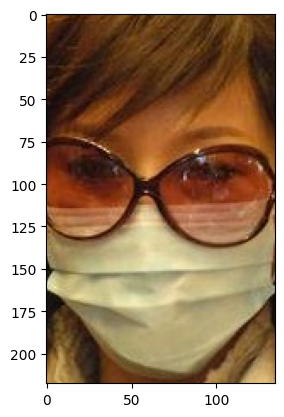

In [22]:
img = mpimg.imread('/content/data/with_mask/with_mask_10.jpg')
plt.imshow(img)

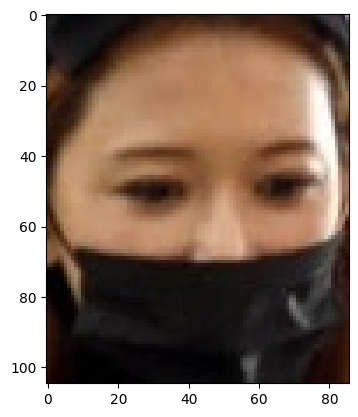

In [23]:
img = mpimg.imread('/content/data/with_mask/with_mask_100.jpg')
plt.imshow(img)

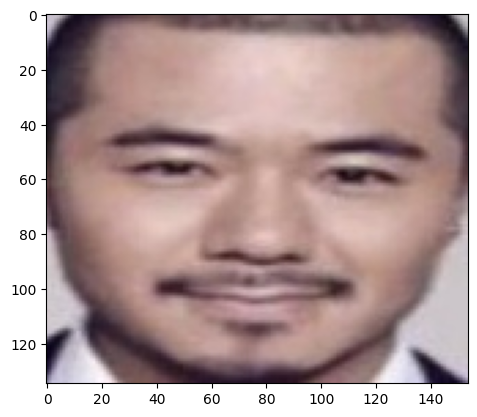

In [24]:
img = mpimg.imread('/content/data/without_mask/without_mask_10.jpg')
plt.imshow(img)

In [25]:
os.mkdir('with_mask_resized')
os.mkdir('without_mask_resized')

In [26]:
with_mask_folder = '/content/data/with_mask/'
with_mask_resized_folder = '/content/with_mask_resized/'
for filename in os.listdir(with_mask_folder):
  img_path = with_mask_folder + filename
  img = Image.open(img_path)
  img = img.resize((128,128))
  img = img.convert('RGB')

  newImgPath = with_mask_resized_folder + filename
  img.save(newImgPath)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [27]:
without_mask_folder = '/content/data/without_mask/'
without_mask_resized_folder = '/content/without_mask_resized/'
for filename in os.listdir(without_mask_folder):
  img_path = without_mask_folder + filename
  img = Image.open(img_path)
  img = img.resize((128,128))
  img = img.convert('RGB')

  newImgPath = without_mask_resized_folder + filename
  img.save(newImgPath)

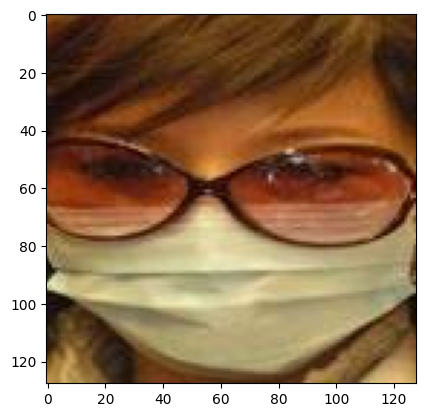

In [28]:
img = mpimg.imread('/content/with_mask_resized/with_mask_10.jpg')
plt.imshow(img)

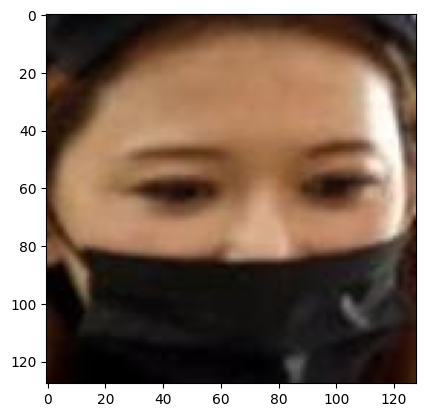

In [29]:
img = mpimg.imread('/content/with_mask_resized/with_mask_100.jpg')
plt.imshow(img)

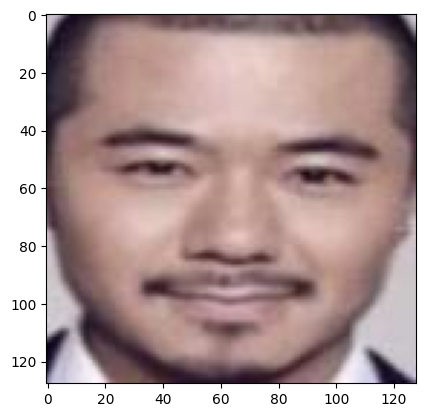

In [30]:
img = mpimg.imread('/content/without_mask_resized/without_mask_10.jpg')
plt.imshow(img)

In [31]:
import cv2
import glob

In [32]:
# reading with_mask images
imdir = '/content/with_mask_resized/'
ext = ['png','jpg']

files = []
[files.extend(glob.glob(imdir + '*.'+ e)) for e in ext]

with_mask_images = np.asarray([cv2.imread(file) for file in files])

In [33]:

# reading without_mask images
imdir = '/content/without_mask_resized/'
ext = ['png','jpg']

files = []
[files.extend(glob.glob(imdir + '*.'+ e)) for e in ext]

without_mask_images = np.asarray([cv2.imread(file) for file in files])

In [34]:
print(with_mask_images)

[[[[128 186 235]
   [126 184 233]
   [127 183 230]
   ...
   [ 97 203 255]
   [ 94 200 254]
   [ 91 197 251]]

  [[129 187 236]
   [128 186 235]
   [130 186 233]
   ...
   [ 98 204 255]
   [ 96 201 255]
   [ 94 199 255]]

  [[129 187 236]
   [130 188 237]
   [133 189 236]
   ...
   [ 95 198 255]
   [ 91 193 252]
   [ 88 190 249]]

  ...

  [[ 37  11 171]
   [ 39  13 173]
   [ 43  15 175]
   ...
   [109  50 225]
   [112  50 226]
   [111  49 225]]

  [[ 37  13 175]
   [ 40  13 176]
   [ 43  14 177]
   ...
   [111  52 227]
   [115  53 229]
   [114  53 227]]

  [[ 39  15 177]
   [ 40  16 178]
   [ 44  14 179]
   ...
   [111  52 227]
   [115  54 228]
   [115  54 228]]]


 [[[ 74  85 107]
   [ 86  97 119]
   [ 95 101 124]
   ...
   [220 246 230]
   [219 247 228]
   [226 254 235]]

  [[ 90 100 124]
   [ 91 102 124]
   [ 93  98 123]
   ...
   [219 245 229]
   [218 245 229]
   [221 248 232]]

  [[ 94 103 130]
   [ 85  95 119]
   [ 84  88 116]
   ...
   [222 247 233]
   [222 248 234]
   [220 246

In [35]:
print(without_mask_images)

[[[[  0   2   0]
   [  0   2   0]
   [  0   2   0]
   ...
   [  0   0   0]
   [  0   0   0]
   [  0   0   0]]

  [[  0   2   0]
   [  0   2   0]
   [  0   2   0]
   ...
   [  0   0   0]
   [  0   0   0]
   [  0   0   0]]

  [[  0   1   0]
   [  0   1   0]
   [  0   1   0]
   ...
   [  0   0   0]
   [  0   0   0]
   [  0   0   0]]

  ...

  [[  0   0   0]
   [  0   0   0]
   [  0   0   0]
   ...
   [  2   0   1]
   [  4   0   3]
   [  4   0   3]]

  [[  0   0   0]
   [  0   0   0]
   [  0   0   0]
   ...
   [  2   0   1]
   [  2   0   3]
   [  2   0   3]]

  [[  0   0   0]
   [  0   0   0]
   [  0   0   0]
   ...
   [  2   0   1]
   [  2   0   3]
   [  2   0   3]]]


 [[[ 47  49  50]
   [ 48  50  51]
   [ 49  51  52]
   ...
   [ 57  65  95]
   [ 58  66  96]
   [ 56  64  94]]

  [[ 46  47  51]
   [ 48  50  51]
   [ 49  50  54]
   ...
   [ 57  65  95]
   [ 56  64  94]
   [ 53  61  91]]

  [[ 46  46  52]
   [ 47  48  52]
   [ 45  48  53]
   ...
   [ 61  69  98]
   [ 58  66  95]
   [ 53  61

In [36]:
print(with_mask_images.shape)
print(without_mask_images.shape)

(3725, 128, 128, 3)
(3828, 128, 128, 3)


In [37]:
combined_image = np.concatenate((with_mask_images, without_mask_images))

In [38]:
print(combined_image.shape)

(7553, 128, 128, 3)


In [39]:
print(combined_image)

[[[[128 186 235]
   [126 184 233]
   [127 183 230]
   ...
   [ 97 203 255]
   [ 94 200 254]
   [ 91 197 251]]

  [[129 187 236]
   [128 186 235]
   [130 186 233]
   ...
   [ 98 204 255]
   [ 96 201 255]
   [ 94 199 255]]

  [[129 187 236]
   [130 188 237]
   [133 189 236]
   ...
   [ 95 198 255]
   [ 91 193 252]
   [ 88 190 249]]

  ...

  [[ 37  11 171]
   [ 39  13 173]
   [ 43  15 175]
   ...
   [109  50 225]
   [112  50 226]
   [111  49 225]]

  [[ 37  13 175]
   [ 40  13 176]
   [ 43  14 177]
   ...
   [111  52 227]
   [115  53 229]
   [114  53 227]]

  [[ 39  15 177]
   [ 40  16 178]
   [ 44  14 179]
   ...
   [111  52 227]
   [115  54 228]
   [115  54 228]]]


 [[[ 74  85 107]
   [ 86  97 119]
   [ 95 101 124]
   ...
   [220 246 230]
   [219 247 228]
   [226 254 235]]

  [[ 90 100 124]
   [ 91 102 124]
   [ 93  98 123]
   ...
   [219 245 229]
   [218 245 229]
   [221 248 232]]

  [[ 94 103 130]
   [ 85  95 119]
   [ 84  88 116]
   ...
   [222 247 233]
   [222 248 234]
   [220 246

In [41]:
# data and labels
X = combined_image
Y = np.asarray(labels)

In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [43]:
print(X.shape, X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (6042,) (1511, 128, 128, 3) (1511,)


In [44]:
print(X_train[0])

[[[250 249 253]
  [253 254 255]
  [237 239 240]
  ...
  [113 119 130]
  [ 98 104 115]
  [165 171 182]]

 [[251 247 253]
  [255 253 255]
  [234 235 239]
  ...
  [137 143 154]
  [111 117 128]
  [143 149 160]]

 [[255 248 255]
  [255 250 255]
  [240 234 245]
  ...
  [119 125 136]
  [ 85  91 102]
  [100 106 117]]

 ...

 [[253 255 255]
  [253 253 253]
  [224 216 216]
  ...
  [ 88  68  50]
  [ 97  71  64]
  [109  82  78]]

 [[248 253 252]
  [243 245 245]
  [216 211 210]
  ...
  [100  79  57]
  [ 98  74  62]
  [106  80  74]]

 [[246 252 251]
  [250 252 252]
  [237 232 231]
  ...
  [145 125 100]
  [133 109  97]
  [140 114 107]]]


In [45]:
X_train_std = X_train/255.0
X_test_std = X_test/255.0

In [46]:
print(X_train_std)

[[[[0.98039216 0.97647059 0.99215686]
   [0.99215686 0.99607843 1.        ]
   [0.92941176 0.9372549  0.94117647]
   ...
   [0.44313725 0.46666667 0.50980392]
   [0.38431373 0.40784314 0.45098039]
   [0.64705882 0.67058824 0.71372549]]

  [[0.98431373 0.96862745 0.99215686]
   [1.         0.99215686 1.        ]
   [0.91764706 0.92156863 0.9372549 ]
   ...
   [0.5372549  0.56078431 0.60392157]
   [0.43529412 0.45882353 0.50196078]
   [0.56078431 0.58431373 0.62745098]]

  [[1.         0.97254902 1.        ]
   [1.         0.98039216 1.        ]
   [0.94117647 0.91764706 0.96078431]
   ...
   [0.46666667 0.49019608 0.53333333]
   [0.33333333 0.35686275 0.4       ]
   [0.39215686 0.41568627 0.45882353]]

  ...

  [[0.99215686 1.         1.        ]
   [0.99215686 0.99215686 0.99215686]
   [0.87843137 0.84705882 0.84705882]
   ...
   [0.34509804 0.26666667 0.19607843]
   [0.38039216 0.27843137 0.25098039]
   [0.42745098 0.32156863 0.30588235]]

  [[0.97254902 0.99215686 0.98823529]
   [0.9

In [47]:
import tensorflow as tf
from tensorflow import keras

In [49]:
model = keras.Sequential([
keras.layers.Flatten(input_shape=(128,128,3)),
keras.layers.Dense(70,activation='relu'),
keras.layers.Dense(70, activation='relu'),
keras.layers.Dense(1,activation='sigmoid')
                          ])

In [50]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy']
              )

In [51]:
model.fit(X_train_std, Y_train, epochs=10)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.6560 - loss: 1.6703
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8092 - loss: 0.4341
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8040 - loss: 0.4631
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.8745 - loss: 0.3140
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.8761 - loss: 0.3070
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.8600 - loss: 0.3328
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8730 - loss: 0.3158
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.8629 - loss: 0.3315
Epoch 9/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.8861 - loss: 0.2876
Epoch 10/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.8829 - loss: 0.2846


In [52]:
score, acc = model.evaluate(X_test_std, Y_test)
print('Test data loss:', score)
print('Test data accuracy:', acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9059 - loss: 0.2717
Test data loss: 0.28836482763290405
Test data accuracy: 0.9020516276359558


In [53]:
from google.colab.patches import cv2_imshow

Path of the image to be predicted :/content/with_mask_resized/with_mask_10.jpg


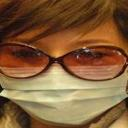

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.8003118]]
1
The person is wearing mask


In [56]:
input_image_path = input('Path of the image to be predicted :')
input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)
input_image_resize = cv2.resize(input_image, (128,128))
input_image_resize = input_image_resize/255

image_reshape = np.reshape(input_image_resize,[1,128,128,3] )
input_prediction = model.predict(image_reshape)
print(input_prediction)

input_pred_label = np.argmax(input_prediction)
input_pred_label = 1 if input_pred_label == 1 else 1
print(input_pred_label)

if input_pred_label == 1:
    print('The person is wearing mask')
else:
    print('The person is not wearing mask')


Path of the image to be predicted :/content/with_mask_resized/with_mask_10.jpg


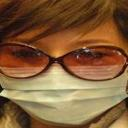

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.8003118]]
0
The person is not wearing mask


In [55]:
input_image_path = input('Path of the image to be predicted :')
input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)
input_image_resize = cv2.resize(input_image, (128,128))
input_image_resize = input_image_resize/255

image_reshape = np.reshape(input_image_resize,[1,128,128,3] )
input_prediction = model.predict(image_reshape)
print(input_prediction)

input_pred_label = np.argmax(input_prediction)
input_pred_label = 0 if input_pred_label == 0 else 1
print(input_pred_label)

if input_pred_label == 1:
    print('The person is wearing mask')
else:
    print('The person is not wearing mask')